In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [150]:
df = pd.read_csv('fcc-forum-pageviews.csv')
df.head(5)
df.set_index(df['date')
# df.info()
# df.describe()
# type(df)

,date,value
0,2016-05-09,1201
1,2016-05-10,2329
2,2016-05-11,1716
3,2016-05-12,10539
4,2016-05-13,6933


In [30]:
df_sorted = df[(df['value']>=df['value'].quantile(0.025)) |
               (df['value']<=df['value'].quantile(0.025))                
              ]


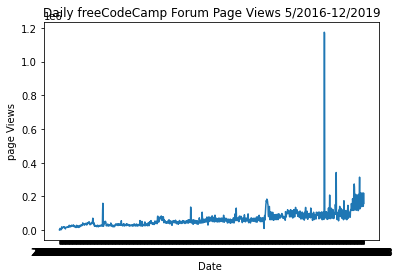

In [31]:
#draw_line_plot
plt.plot(df_sorted['date'],df_sorted['value'])
plt.title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
plt.ylabel('page Views')
plt.xlabel('Date ')
plt.show()

In [53]:
#to confirm the datatype of the value in date column
# type(df.loc[3]['date'])

def sort_date(x):
    
    parts = x.split('-')
    
    year,month,day = parts
   
    return int(year),int(month),int(day)



In [57]:
df_new = df.copy()
#Without pd.Series, pandas treats that tuple as a single object, so you get a Series of tuples—not something that can be split across columns.
#pd.Series(...) tells pandas:
#“Expand this tuple into separate columns.”

df_new[['year','month','day']] =  df['date'].apply(lambda x: pd.Series(sort_date(x)))


In [34]:
df_new

,date,value,year,month,day
0,2016-05-09,1201,2016,05,09
1,2016-05-10,2329,2016,05,10
2,2016-05-11,1716,2016,05,11
3,2016-05-12,10539,2016,05,12
4,2016-05-13,6933,2016,05,13
...,...,...,...,...,...
1299,2019-11-29,171584,2019,11,29
1300,2019-11-30,141161,2019,11,30
1301,2019-12-01,142918,2019,12,01
1302,2019-12-02,220144,2019,12,02


<AxesSubplot:xlabel='year', ylabel='value'>

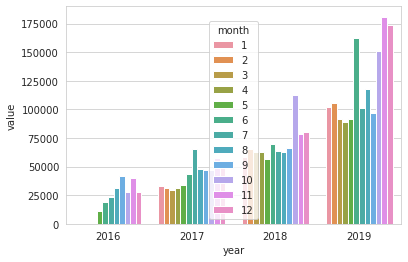

In [143]:
#show average daily page views for each month grouped by year.

daily_avg_view_per_month = df_new.groupby(['year','month'])
daily_avg_view_per_month = daily_avg_view_per_month['value'].mean().reset_index()

type(daily_avg_view_per_month)

sns.barplot(x='year',y='value',hue='month',data=daily_avg_view_per_month)

## BOX-PLOT

<AxesSubplot:title={'center':'value'}, xlabel='year'>

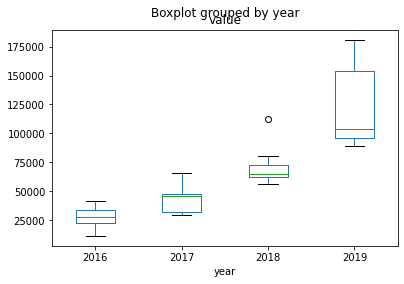

In [135]:
#year wise box plot

daily_avg_view_per_month


daily_avg_view_per_month.boxplot(by='year',column='value',grid=False)






<AxesSubplot:xlabel='year', ylabel='value'>

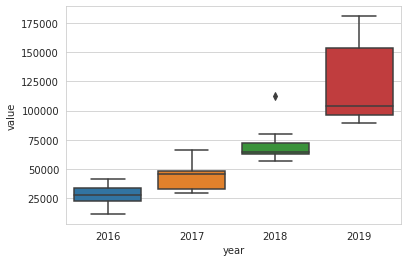

In [146]:
sns.boxplot(x='year',y='value',data=daily_avg_view_per_month)

<AxesSubplot:title={'center':'value'}, xlabel='month'>

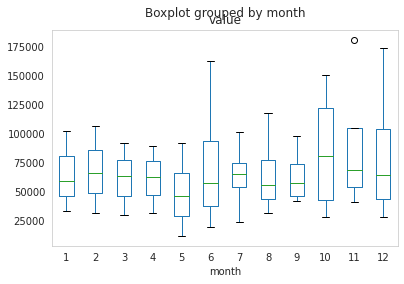

In [142]:
#month wise box plot
daily_avg_view_per_month.boxplot(by='month',column='value',grid=False)




<AxesSubplot:xlabel='month', ylabel='value'>

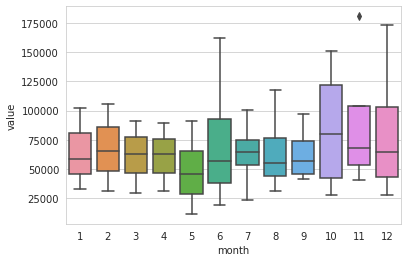

In [145]:
sns.boxplot(x='month',y='value',data=daily_avg_view_per_month)